<a href="https://colab.research.google.com/github/emilleishida/Fink_earlyTDE_v2/blob/main/notebooks/Check_feature_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load data and import packages**

In [4]:
# Run to download necessary files and clone & install light-curve repository

import pathlib
import os

data_dir = '/content'
pathlib.Path(data_dir).mkdir(parents=True, exist_ok=True)

files_to_download = {
    os.path.join(data_dir, "feature_data.csv"): "1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE",
    #os.path.join(data_dir, "mallorn_data_fink_SNR_30d_LCs.pkl"): "1bb1fgySX2KRMFxWLzSpFbLfq3vUOtWtj",
    #os.path.join(data_dir, "mallorn_data_fink_SNR_Full_LCs.pkl"): "1DNk-sk3a2fC1v8dCx6KqyHDjtxMLWi2W",
}

for fpath, fid in files_to_download.items():
    url = f"https://drive.google.com/uc?id={fid}"
    if not os.path.exists(fpath):
        print(f"Downloading {os.path.basename(fpath)}...")
        !gdown "{url}" -O "{fpath}"
    else:
        print(f"{os.path.basename(fpath)} already exists, skipping.")


try:
  from light_curve.light_curve_py import RainbowFit
except ModuleNotFoundError:

  !git clone https://github.com/light-curve/light-curve-python.git
  !pip install 'light-curve[full]'
  from light_curve.light_curve_py import RainbowFit


Downloading...
From: https://drive.google.com/uc?id=1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE
To: /content/feature_data.csv
100% 48.8M/48.8M [00:00<00:00, 62.7MB/s]
Cloning into 'light-curve-python'...
remote: Enumerating objects: 19824, done.
remote: Counting objects: 100% (793/793), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 19824 (delta 742), reused 644 (delta 643), pack-reused 19031 (from 3)
Receiving objects: 100% (19824/19824), 50.62 MiB | 19.55 MiB/s, done.
Resolving deltas: 100% (9020/9020), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 754.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 MB 16.2 MB/s eta 0:00:00


In [13]:
import pandas as pd
def load_features(filename, keep_only_last_alert = False, apply_quality_cuts=True):

  features = pd.read_csv(filename)
  features = features.dropna()
  if apply_quality_cuts:
     features = features[features.passes_feature_quality_cuts]
  if keep_only_last_alert:
    features = features.sort_values("jd_max", ascending = False)
    features = features.drop_duplicates("object_id")

  return features

# Load features keeping only the last alert
features = load_features("feature_data.csv")
features_no_quality_cuts = load_features("feature_data.csv", apply_quality_cuts = False)
features_last = load_features("feature_data.csv", keep_only_last_alert = True)
features_last_no_cuts = load_features("feature_data.csv", keep_only_last_alert = True, apply_quality_cuts = False)



# **Plotting**

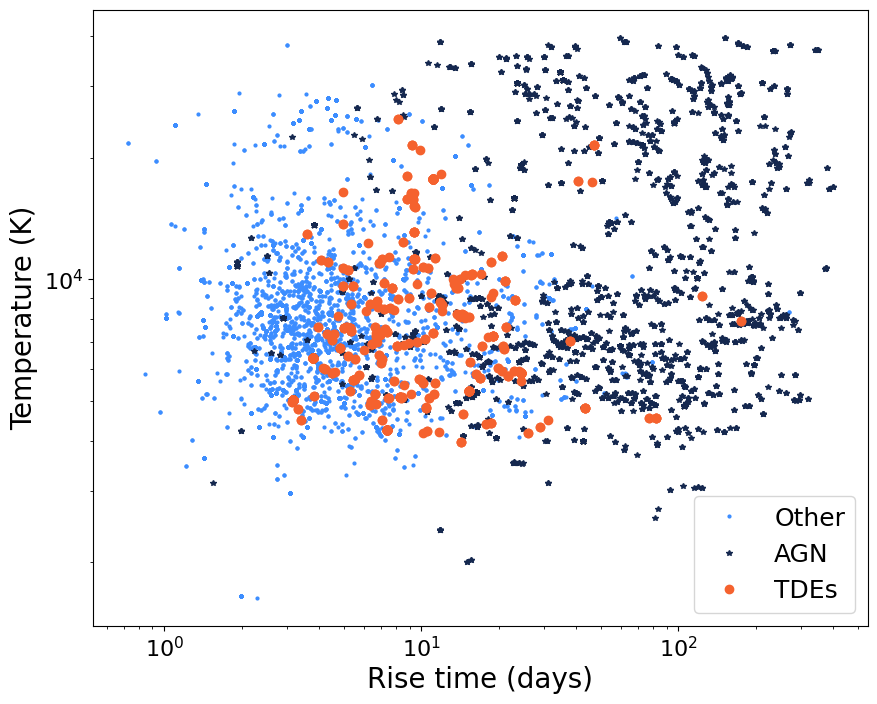

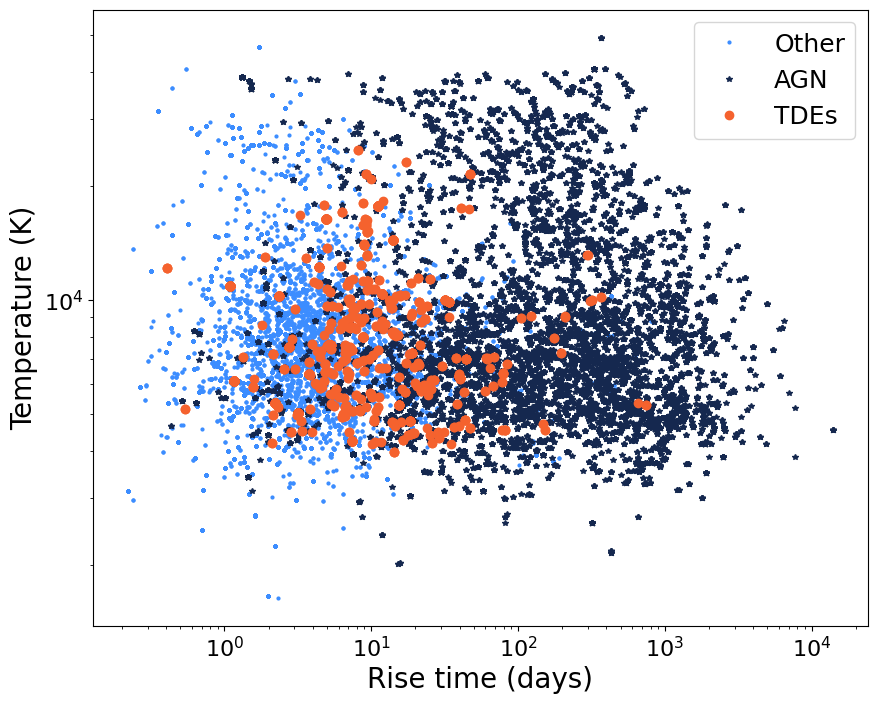

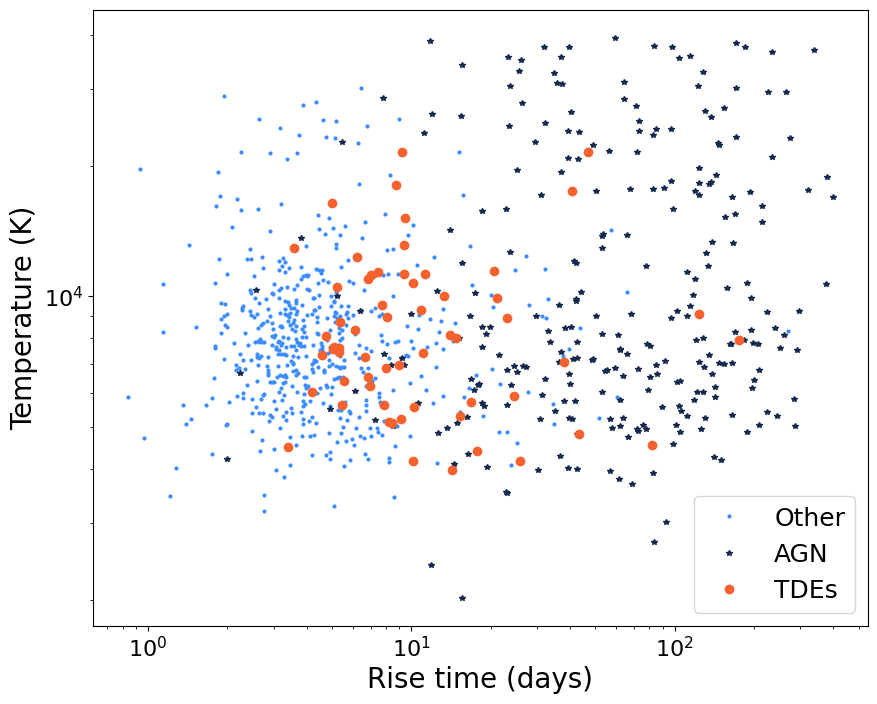

In [6]:
import matplotlib.pyplot as plt
COLORS_ZTF = {1: "#15284F", 2: "#F5622E", 3: "#3C8DFF", 4: "#D5D5D3"}


def plot_temperature_vs_rise_time(feat_df):

    ax = plt.figure(figsize=(10,8)).gca()
    COLORS_ZTF = {1: "#15284F", 2: "#F5622E", 3: "#3C8DFF", 4: "#D5D5D3"}

    agn_index = feat_df.SpecType == "AGN"
    tde_idx = feat_df.SpecType == "TDE"

    plt.plot(feat_df['rise_time'][~tde_idx & ~agn_index], feat_df['temperature'][~tde_idx & ~agn_index], '.', ms=4, color=COLORS_ZTF[3], label='Other', rasterized=True)
    plt.plot(feat_df['rise_time'][agn_index], feat_df['temperature'][agn_index], '*', color=COLORS_ZTF[1], ms = 4, label='AGN', rasterized=True)
    plt.plot(feat_df['rise_time'][tde_idx], feat_df['temperature'][tde_idx], 'o', color=COLORS_ZTF[2], ms=6, label='TDEs')


    # plt.legend(fontsize=18)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Rise time (days)', fontsize = 20)
    plt.ylabel('Temperature (K)', fontsize = 20)
    plt.tick_params(axis='both', which='major', labelsize=16) #, width=2.5, length=10)
    # plt.grid(alpha=0.2)
    # plt.xlim(3e-1, 3e2)
    # plt.ylim(2e3, 5e4)

    ax.legend(fontsize = 18)

plot_temperature_vs_rise_time(features)
plot_temperature_vs_rise_time(features_no_quality_cuts)
plot_temperature_vs_rise_time(features_last)




In [20]:
def corner_plot(feat_df):
    cols = ['rise_time', 'temperature', 'amplitude', 'r_chisq', 'snr_amplitude', 'snr_rise_time', 'snr_temperature', 'norm_rel_reference_time', 'e_reference_time']

    agn_index = feat_df.SpecType == "AGN"
    tde_idx = feat_df.SpecType == "TDE"

    Nx = Ny = len(cols) - 1

    plt.figure(figsize=(18,12))
    for iy in range(Ny):
        for ix in range(0, iy+1):
            col1,col2 = cols[ix], cols[iy+1]

            plt.subplot(Nx, Ny, ix + iy*Nx + 1)
            plt.grid(alpha=0.2)

            if ix == 0:
                plt.ylabel(col2, rotation=105, labelpad=20)
            if iy == Ny - 1:
                plt.xlabel(col1, rotation=15)

            # Main plotting
            plt.plot(feat_df[col1][~tde_idx & ~agn_index], feat_df[col2][~tde_idx & ~agn_index], '.', ms=2, color=COLORS_ZTF[3], label='Other', rasterized=True)
            plt.plot(feat_df[col1][agn_index], feat_df[col2][agn_index], '*', color=COLORS_ZTF[1], ms = 2, label='AGN', rasterized=True)
            plt.plot(feat_df[col1][tde_idx], feat_df[col2][tde_idx], 'o', color=COLORS_ZTF[2], ms=3, label='TDEs')


            if col1 == 'rise_time':
                plt.xscale('log')
                plt.xlim(1e-1, )
            if col2 == 'rise_time':
                plt.yscale('log')
                plt.ylim(1e-1, )

            if col1 == 'temperature':
                plt.xscale('log')
                plt.xlim(None, 1e5)
            if col2 == 'temperature':
                plt.yscale('log')
                plt.ylim(None, 1e5)

            if col1.startswith('snr_') or col1 in ['e_reference_time', 'r_chisq', 'amplitude', 'distnr']:
                plt.xscale('log')
            if col2.startswith('snr_') or col2 in ['e_reference_time', 'r_chisq', 'amplitude', 'distnr']:
                plt.yscale('log')

            if ix > 0:
                plt.gca().set_yticklabels([])
            if iy < Ny - 1:
                plt.gca().set_xticklabels([])

            if ix == 0 and iy == 0:
                legend = plt.legend(loc=(1.05, 0.1), frameon=False, )
            for _ in legend.legend_handles:
                _.set_alpha(1)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=0.05)


## **Corner plots**
### 1. All features, after quality cuts

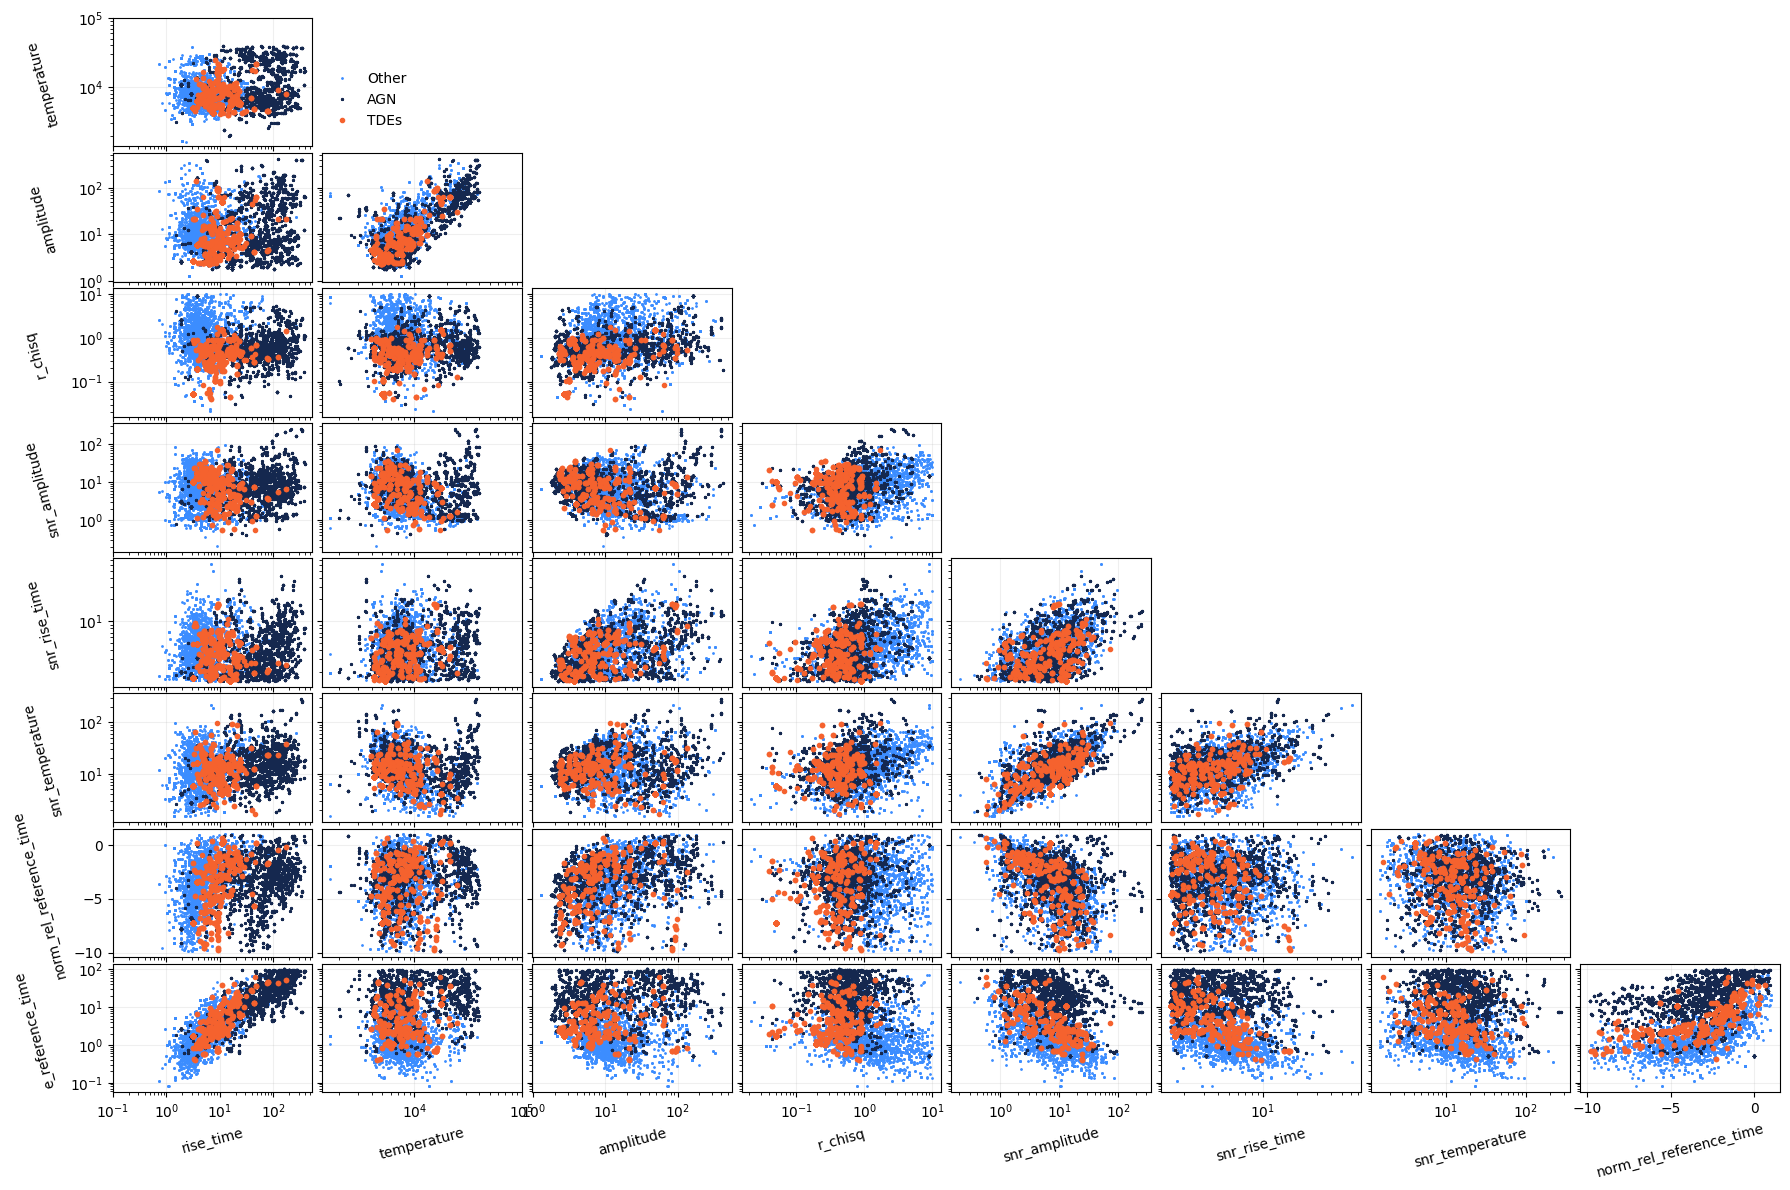

In [21]:
corner_plot(features)


### 2. Features with only last alert per object, after quality cuts.

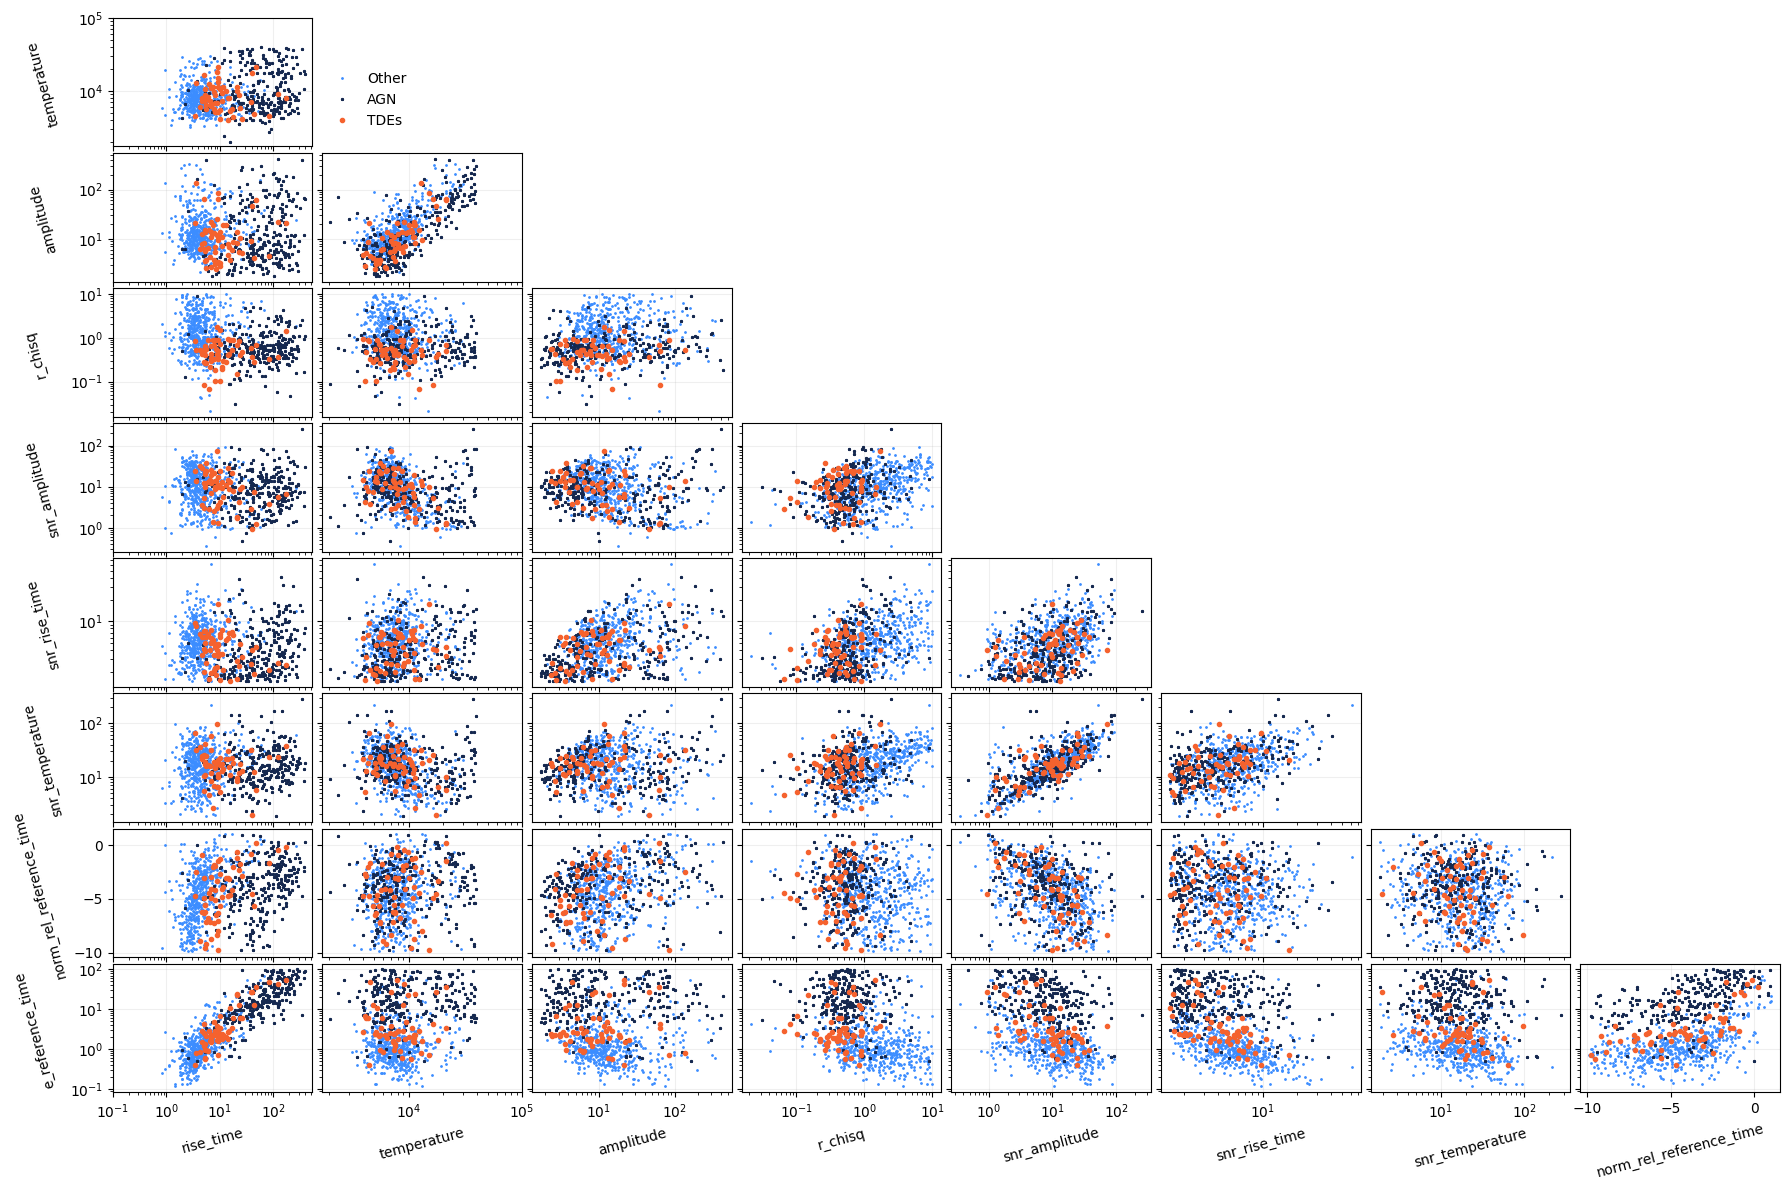

In [23]:
corner_plot(features_last)


### 3. Features with only last alert per object, **no** quality cuts.


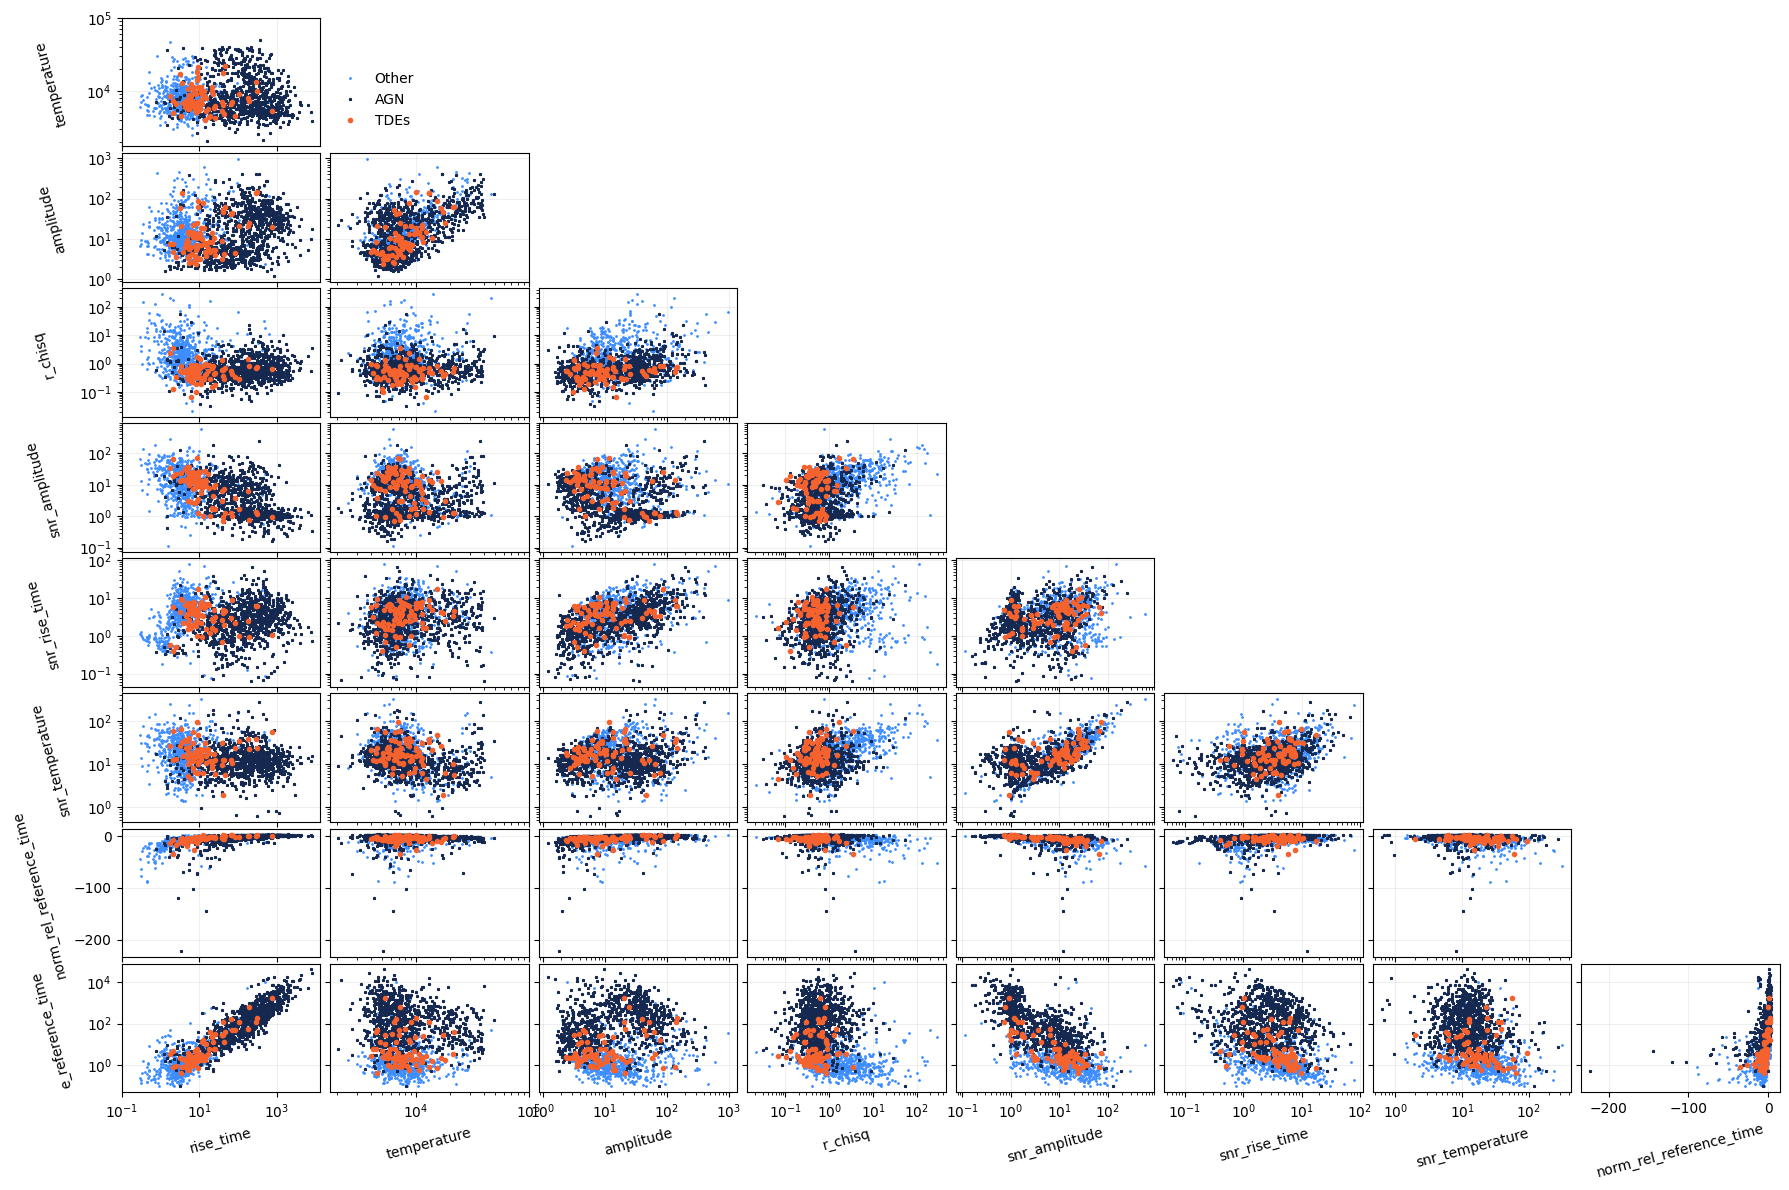

In [25]:
corner_plot(features_last_no_cuts)


### 4. All features **no** quality cuts.


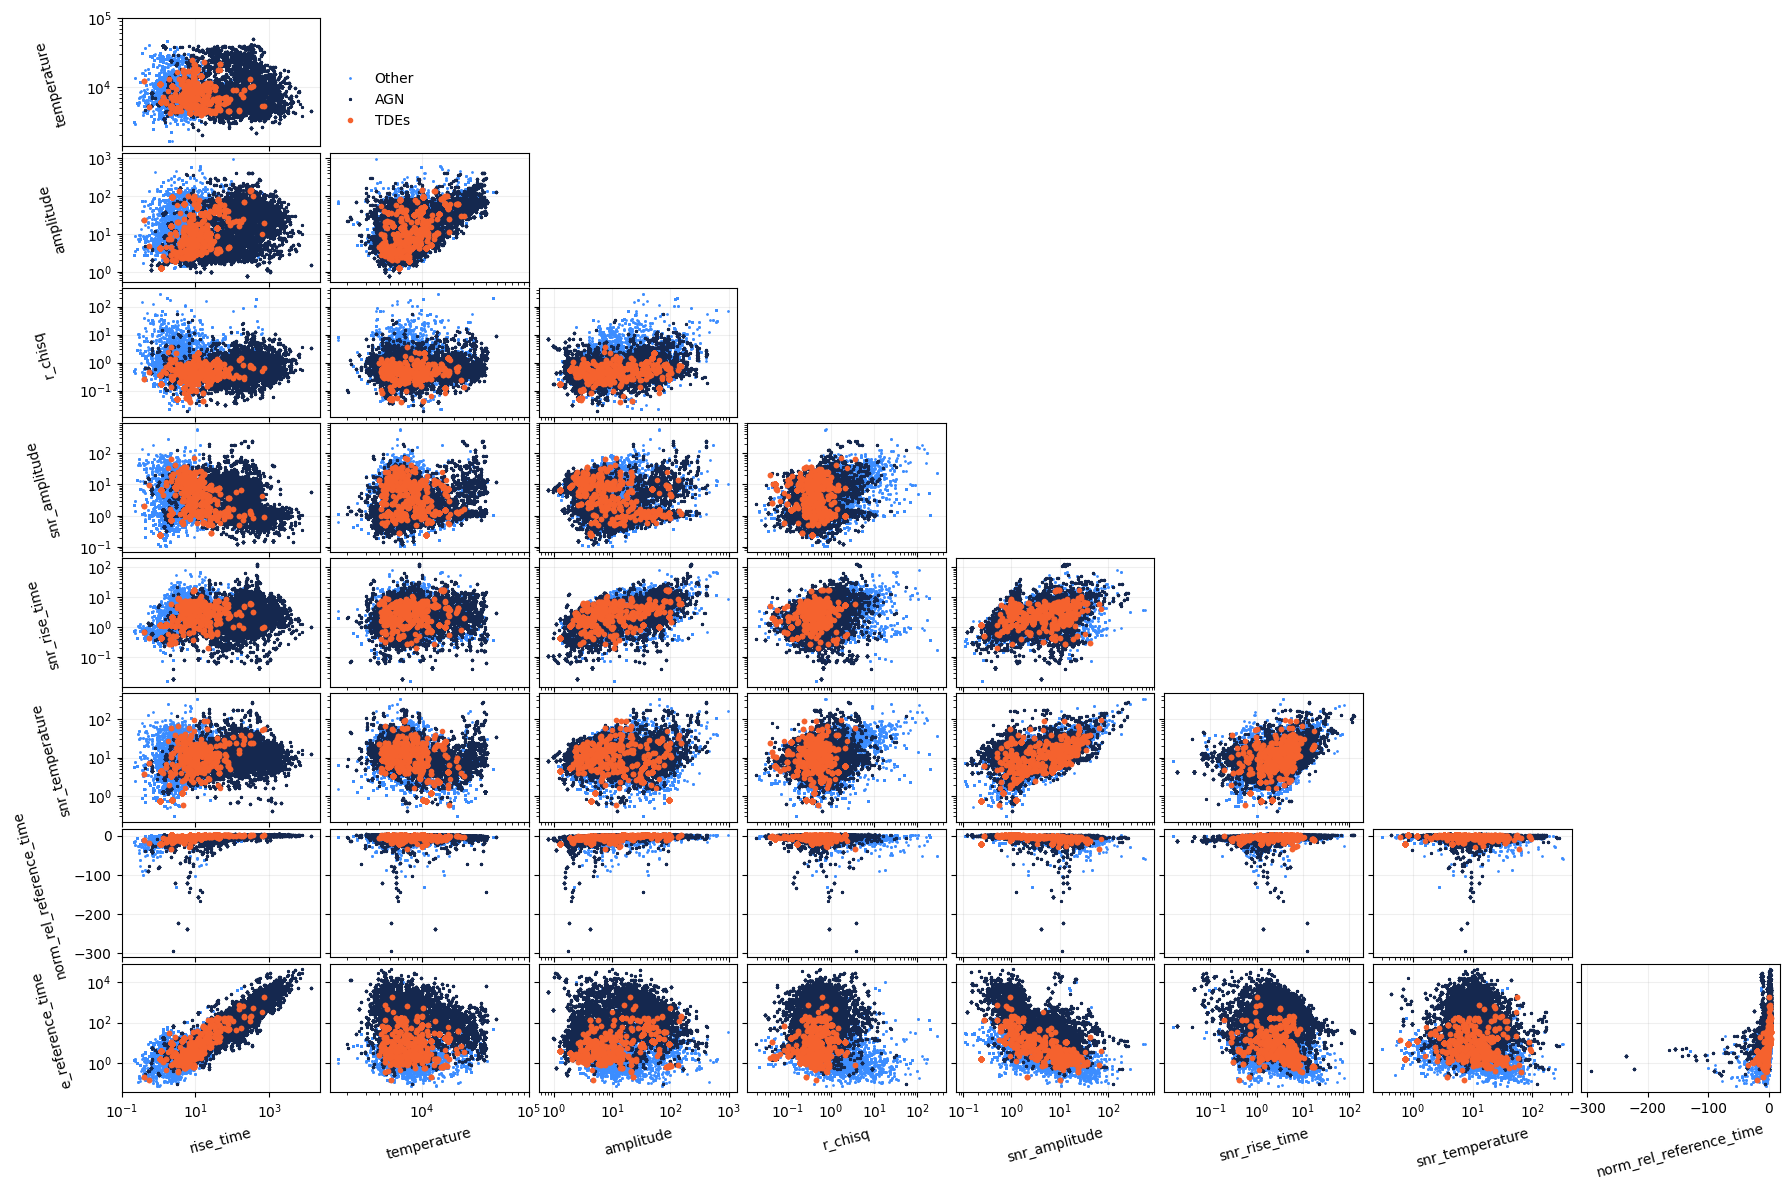

In [24]:
corner_plot(features_no_quality_cuts)
